In [ ]:
import pandas as pd
import numpy as np
import requests
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
from bs4 import BeautifulSoup

warnings.filterwarnings("ignore")

In [ ]:
url = 'https://renatomaaliw3.github.io/prelims.html'

headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/134.0.0.0 Safari/537.36'}

response = requests.get(url = url, headers = headers)

soup = BeautifulSoup(response.content, 'html.parser')

In [ ]:
# Web scraping the dataset SET A

table = soup.find("table", {"id": "set_a"})
data = []

for row in table.find_all('tr')[1:]:
    cols = row.find_all('td')

# Conversion to date & float and Resetting indices
    if len(cols) >= 2:
        date = pd.to_datetime(cols[0].text.strip(), errors='coerce')
        value = pd.to_numeric(cols[1].text.strip(), errors='coerce')
        data.append([date, value])

df_set_a = pd.DataFrame(data, columns=["Date", "Value"])

df_set_a.dropna(inplace=True)
df_set_a.set_index("Date", inplace=True)
df_set_a.sort_index(inplace=True)

df_set_a = df_set_a.asfreq('D')
df_set_a.fillna(method='ffill', inplace=True)

df_set_a

,Value
Date,
1979-01-01,0.993428
1979-01-02,0.223471
1979-01-03,2.295377
1979-01-04,4.546060
1979-01-05,1.531693
...,...
1981-09-22,496.937799
1981-09-23,501.595373
1981-09-24,499.781686


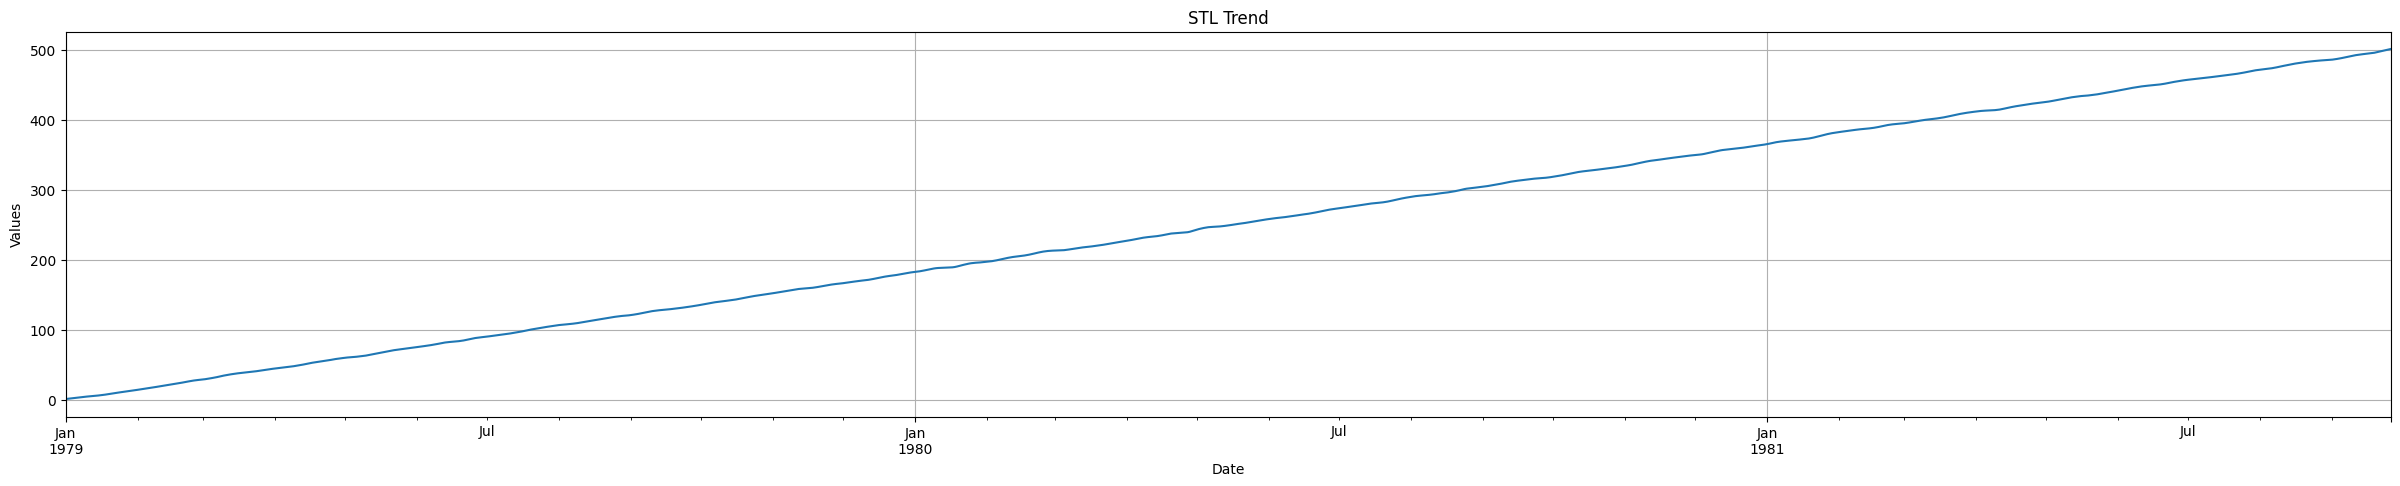

In [ ]:
from statsmodels.tsa.seasonal import STL

# STL Trend
ts_stl = STL(df_set_a["Value"], robust = True)
decomp_stl = ts_stl.fit()

decomp_stl.trend.plot(figsize = (30,5), grid = True, ylabel = 'Values', title = 'STL Trend')
plt.show()

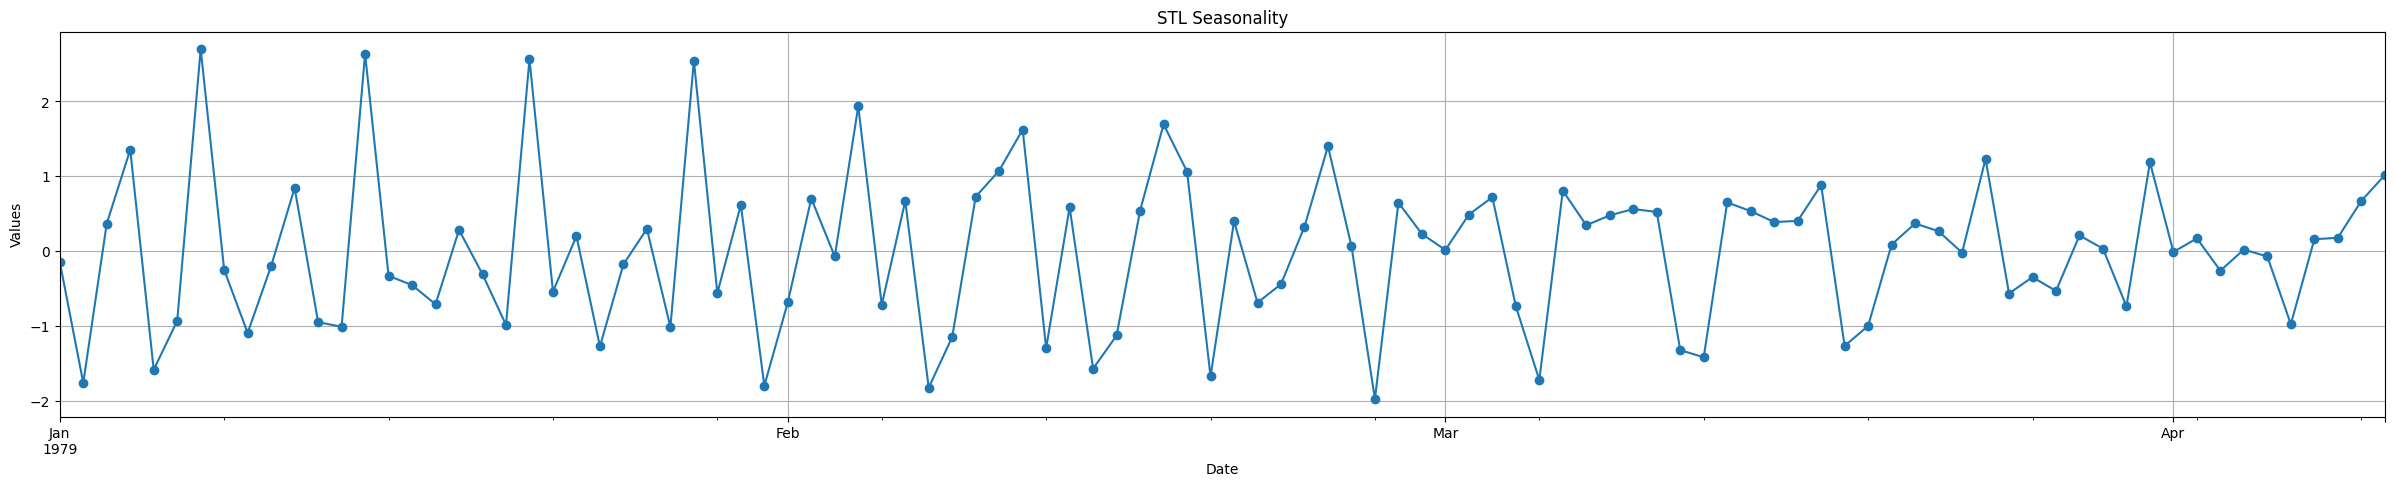

In [ ]:
# STL Seasonality

decomp_stl.seasonal[:100].plot(figsize = (30,5), grid = True, ylabel = 'Values', title = 'STL Seasonality', marker = 'o')
plt.show()

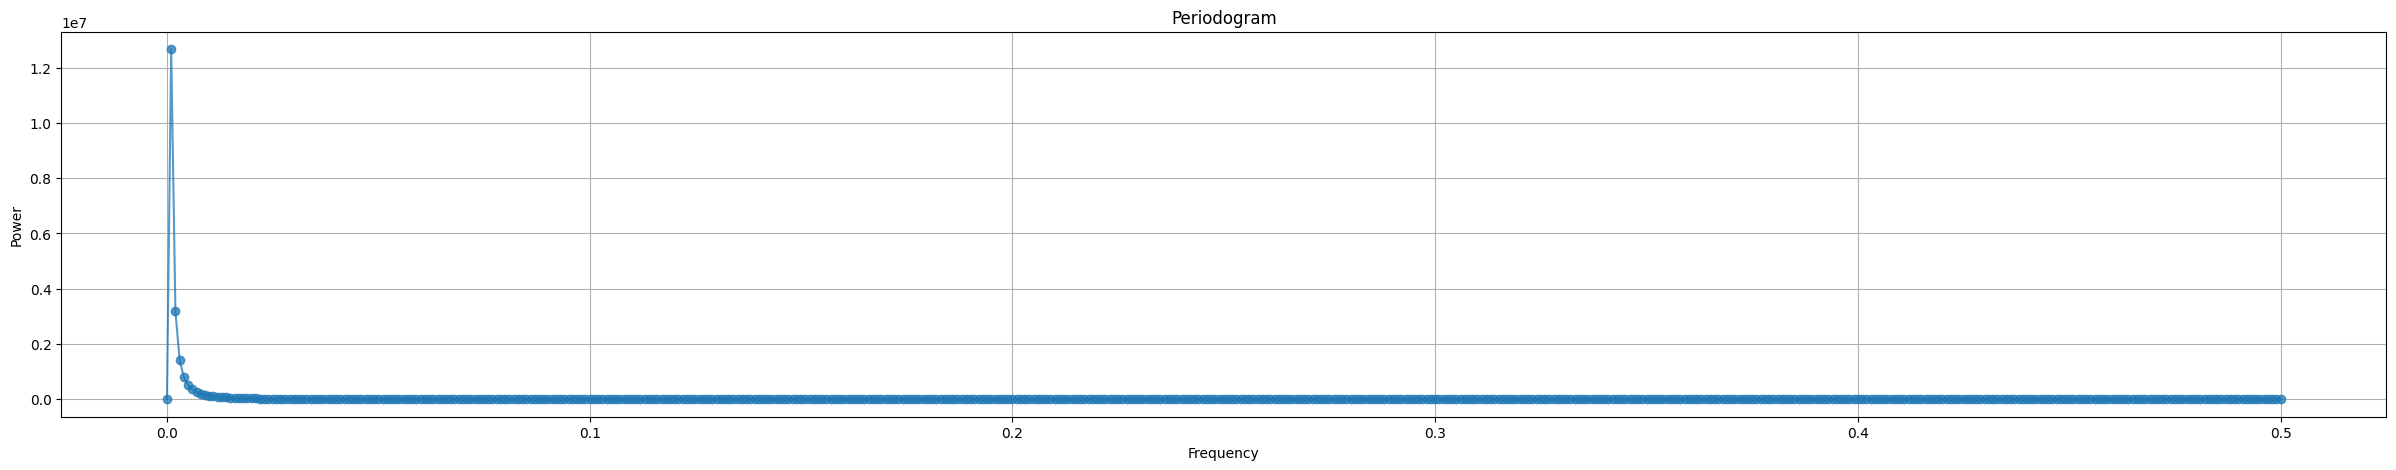

In [ ]:
# Other way to check if there is seasonality

# Using Periodogram (for Seasonality)

from scipy.signal import periodogram
frequencies, power = periodogram(df_set_a['Value'])

plt.figure(figsize=(30, 5))
plt.plot(frequencies, power, marker='o', linestyle='-', alpha = 0.75)
plt.title("Periodogram")
plt.xlabel("Frequency")
plt.ylabel("Power")
plt.grid(True)
plt.show()

**As shown in the graph, there is Trend but no Seasonality. Therefore, the appropriate model for this dataset is DES**

Forecasted value on the 14th day: 496.16


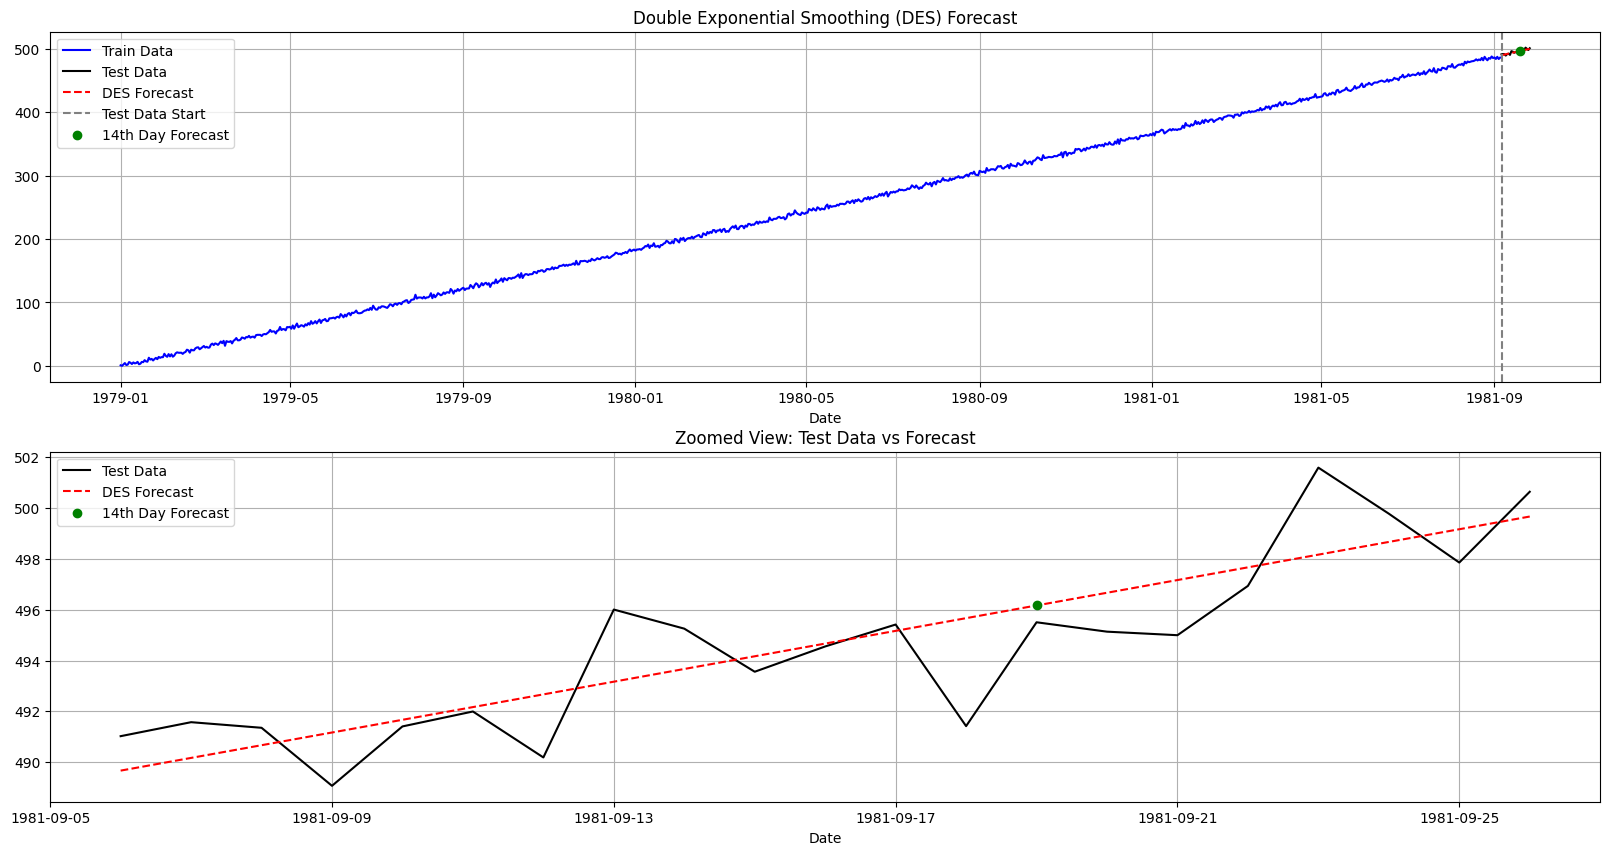

In [ ]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

forecast_horizon = 21
train_data = df_set_a.iloc[:-forecast_horizon]
test_data = df_set_a.iloc[-forecast_horizon:]

train_data = train_data.asfreq('D')
test_data = test_data.asfreq('D')

des_model = ExponentialSmoothing(train_data["Value"], trend="additive").fit()
des_pred = des_model.forecast(forecast_horizon)

forecast_14th_day = des_pred.iloc[13]

print(f"Forecasted value on the 14th day: {f'{forecast_14th_day:.4f}'[:-2]}")

plt.figure(figsize=(20, 10))

plt.subplot(2, 1, 1)
plt.plot(train_data.index, train_data["Value"], label="Train Data", color='blue')
plt.plot(test_data.index, test_data["Value"], label="Test Data", color='black')
plt.plot(des_pred.index, des_pred, label="DES Forecast", color='red', linestyle="dashed")
plt.axvline(test_data.index[0], color='gray', linestyle="--", label="Test Data Start")
plt.scatter(des_pred.index[13], forecast_14th_day, color='green', label="14th Day Forecast", zorder=3)
plt.legend()
plt.grid()
plt.xlabel("Date")
plt.title("Double Exponential Smoothing (DES) Forecast")

plt.subplot(2, 1, 2)
plt.plot(test_data.index, test_data["Value"], label="Test Data", color='black')
plt.plot(des_pred.index, des_pred, label="DES Forecast", color='red', linestyle="dashed")
plt.scatter(des_pred.index[13], forecast_14th_day, color='green', label="14th Day Forecast", zorder=3)
plt.legend()
plt.grid()
plt.xlabel("Date")
plt.title("Zoomed View: Test Data vs Forecast")

plt.show()

Forecasted value on the 21st day: 510.16


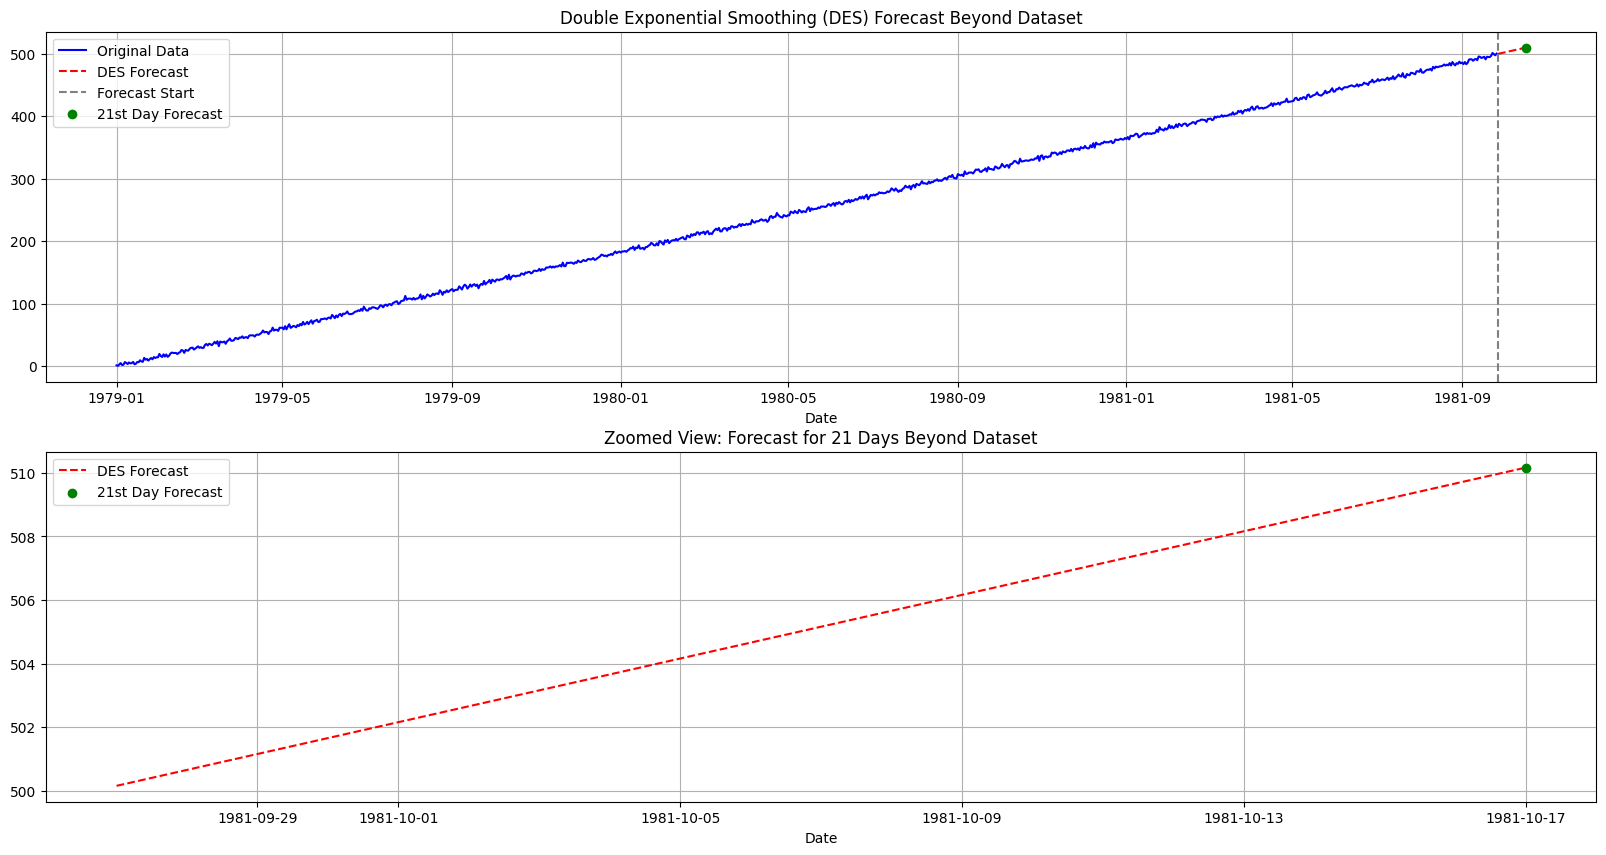

In [ ]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

forecast_horizon = 21
df_set_a = df_set_a.asfreq('D')

des_model = ExponentialSmoothing(df_set_a["Value"], trend="additive").fit()

des_pred = des_model.forecast(forecast_horizon)
forecast_21st_day = des_pred.iloc[-1]

print(f"Forecasted value on the 21st day: {f'{forecast_21st_day:.4f}'[:-2]}")

plt.figure(figsize=(20, 10))

plt.subplot(2, 1, 1)
plt.plot(df_set_a.index, df_set_a["Value"], label="Original Data", color='blue')
plt.plot(des_pred.index, des_pred, label="DES Forecast", color='red', linestyle="dashed")
plt.axvline(des_pred.index[0], color='gray', linestyle="--", label="Forecast Start")
plt.scatter(des_pred.index[-1], forecast_21st_day, color='green', label="21st Day Forecast", zorder=3)
plt.legend()
plt.grid()
plt.xlabel("Date")
plt.title("Double Exponential Smoothing (DES) Forecast Beyond Dataset")

plt.subplot(2, 1, 2)
plt.plot(des_pred.index, des_pred, label="DES Forecast", color='red', linestyle="dashed")
plt.scatter(des_pred.index[-1], forecast_21st_day, color='green', label="21st Day Forecast", zorder=3)
plt.legend()
plt.grid()
plt.xlabel("Date")
plt.title("Zoomed View: Forecast for 21 Days Beyond Dataset")

plt.show()